# Example 1 — Koopman–Luenberger Observer for an Asymptotically Stable Nonlinear System

We apply the data-driven Koopman–Luenberger observer to the two-state nonlinear system

$$
\dot{x}_1 = \frac{3 - x_1}{4} - \frac{9(1+x_1)}{4(3+2x_1)}, \qquad
\dot{x}_2 = -\frac{3(1+x_2)}{4} + \frac{9(1+x_1)}{4(3+2x_1)}, \qquad
y = x_1.
$$

The unique equilibrium is at $x^* = (0,0)$, with Jacobian eigenvalues $-5/4$ and $-3/4$
(locally asymptotically stable).  
The singularity of the vector field at $x_1 = -3/2$ is avoided by restricting data to
$x_1 \in [-L/2,\, L/2]$ with $L <3$ (`side_lengths` below).

**Workflow:**
1. Set all hyperparameters in the `HP` dictionary (next cell)
2. Run all remaining cells in order — each step is timed and a summary table is printed at the end

In [1]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from dynamical_system import DynamicalSystem, synthesize_observer_gain, simulate_koopman_observer
from kernel import linear_kernel, sobolev_kernel

warnings.filterwarnings("ignore")
timings = {}   # wall-clock times filled in by each step cell

## Hyperparameters

Edit **only this cell** to explore the effect of each hyperparameter.
All downstream cells read from `HP` and require no further edits.

| Key | Symbol | Role |
|---|---|---|
| `lam` | $\lambda$ | Yosida regularisation parameter (larger = finer generator approximation) |
| `tau` | $\tau$ | Trajectory duration used for the Yosida integral (s) |
| `n` | $n$ | Number of basis (data) points |
| `side_lengths` | $L$ | Sampling domain: each state drawn from $[-L/2,\, L/2]$ |
| `s` | $s$ | Sobolev index of the kernel $\kappa_{\mathrm{Sob}}$ (smoothness) |
| `length_scale` | $\ell$ | Length scale of the Sobolev kernel |
| `k` | $k$ | Forcing constant in the LMI (paper Eq. 19) |
| `eps` | $\varepsilon$ | Gram-matrix regularisation: $G \leftarrow K_0 + \varepsilon I$ |
| `delta` | $\delta$ | Strict PD lower bound on $\tilde{P}$: $\tilde{P} \succ \delta I$ |
| `margin` | — | Strict negativity margin in the LMI: $\preceq -\text{margin}\cdot I$ |

In [2]:
HP = {
    # ── Yosida approximation ──────────────────────────────────────────────
    "lam":          5.0,   # λ
    "tau":          3.0,   # τ  (seconds)
    # ── Data ─────────────────────────────────────────────────────────────
    "n":            64,    # number of basis points
    "side_lengths": 2.0,   # sampling domain L  (x_i ∈ [−L/2, L/2])
    # ── Kernel ───────────────────────────────────────────────────────────
    "s":            2.5,   # Sobolev index
    "length_scale": 1.0,   # kernel length scale ℓ
    # ── LMI ──────────────────────────────────────────────────────────────
    "k":            10.0,  # forcing constant (paper Eq. 19)
    "eps":          1e-2,  # Gram-matrix regularisation
    "delta":        1.0,   # P̃ ≻ δ I
    "margin":       1e-2,  # LMI strict negativity margin
}

## System definition

In [3]:
def f_ex1(x):
    x1, x2 = x[0], x[1]
    reaction = 9.0 * (1.0 + x1) / (4.0 * (3.0 + 2.0 * x1))
    return np.array([
        (3.0 - x1) / 4.0 - reaction,
        -3.0 * (1.0 + x2) / 4.0 + reaction,
    ])

sys1 = DynamicalSystem(
    f=f_ex1,
    h=lambda x: np.array([x[0]]),
    n_states=2, n_outputs=1,
    name="Ex1-AsymStable",
)

# Sanity check: equilibrium and local Jacobian eigenvalues
print(f"f(0, 0)                    = {f_ex1(np.zeros(2))}  (should be [0, 0])")
J_analytic = np.array([[-5/4, 0.0], [1.0, -3/4]])
print(f"Jacobian eigenvalues at 0  = {np.linalg.eigvals(J_analytic)}  (both < 0)")

f(0, 0)                    = [0. 0.]  (should be [0, 0])
Jacobian eigenvalues at 0  = [-0.75 -1.25]  (both < 0)


## Step 1 — Data collection

In [4]:
t_eval_data = np.linspace(0.0, HP["tau"], 31)   # 31 points shared across trajectories

t0 = time.perf_counter()
data1 = sys1.collect_data(
    side_lengths=HP["side_lengths"],
    n=HP["n"],
    tau=HP["tau"],
    t_eval=t_eval_data,
    rng=np.random.default_rng(0),
)
timings["1. Data collection"] = time.perf_counter() - t0

print(f"Data collection : {timings['1. Data collection']:.3f} s")
print(f"  n_samples     : {data1.n_samples}")
print(f"  X_data shape  : {data1.X_data.shape}")
print(f"  Y_data shape  : {data1.Y_data.shape}")

Data collection : 0.100 s
  n_samples     : 64
  X_data shape  : (2, 64)
  Y_data shape  : (1, 64)


## Step 2 — Kernel matrix computation

Product kernel $\kappa = \kappa_{\mathrm{lin}} \cdot \kappa_{\mathrm{Sob}}$;  
forms $K_0$ (Gram matrix) and $M$ (Yosida generator matrix $G'$, paper Eq. 16).

In [5]:
kappa = linear_kernel() * sobolev_kernel(
    d=sys1.n_states,
    s=HP["s"],
    length_scale=HP["length_scale"],
)

t0 = time.perf_counter()
K0, M = data1.compute_kernel_matrices(kappa, HP["lam"])
timings["2. Kernel matrices"] = time.perf_counter() - t0

print(f"Kernel matrices : {timings['2. Kernel matrices']:.3f} s")
print(f"  K0 shape      : {K0.shape},  cond(K0) = {np.linalg.cond(K0):.2e}")
print(f"  M  shape      : {M.shape},   ||M||_F  = {np.linalg.norm(M):.4f}")

Kernel matrices : 0.009 s
  K0 shape      : (64, 64),  cond(K0) = 1.57e+06
  M  shape      : (64, 64),   ||M||_F  = 12.4117


## Step 3 — Observer gain synthesis

Solves the LMI (paper Eq. 19) via MOSEK with variables $\tilde{P} = GPG$, $\tilde{Y} = GY$.  
Returns the innovation gain $L = \tilde{P}^{-1}\tilde{Y}$ directly.

In [6]:
t0 = time.perf_counter()
result1 = synthesize_observer_gain(
    data1, kappa, lam=HP["lam"],
    k=HP["k"], eps=HP["eps"], delta=HP["delta"], margin=HP["margin"],
    verbose=False,
)
timings["3. Observer synthesis"] = time.perf_counter() - t0

A_cl1   = result1["A"] - result1["L"] @ data1.Y_data
max_re1 = np.linalg.eigvals(A_cl1).real.max()

print(f"Observer synthesis : {timings['3. Observer synthesis']:.3f} s")
print(f"  Solver status    : {result1['status']}")
print(f"  max Re(eig(A_cl)): {max_re1:.6f}  ({'STABLE' if max_re1 < 0 else 'UNSTABLE'})")
print(f"  ||L||_F          : {np.linalg.norm(result1['L']):.4f}")

Observer synthesis : 2.059 s
  Solver status    : optimal
  max Re(eig(A_cl)): -0.002618  (STABLE)
  ||L||_F          : 23.6323


## Step 4 — Observer simulation

Integrates the observer ODE (paper Eq. 23) over $[0, 30]$ s from $z_0 = 0$.  
True trajectory starts at $x_0 = (1, 1)$.

In [7]:
x0_true = np.array([1.0, 1.0])
t_sim   = np.linspace(0.0, 30.0, 600)

sol_true = solve_ivp(
    lambda t, x: sys1.vector_field(x),
    [t_sim[0], t_sim[-1]], x0_true,
    method="Radau", rtol=1e-9, atol=1e-11,
    dense_output=True, t_eval=t_sim,
)
y_func1 = lambda t: sys1.output(sol_true.sol(t))
x_true1 = sol_true.y

t0 = time.perf_counter()
obs1 = simulate_koopman_observer(
    result1, data1, y_func1,
    z0=np.zeros(data1.n_samples),
    t_span=(t_sim[0], t_sim[-1]), t_eval=t_sim,
)
timings["4. Observer simulation"] = time.perf_counter() - t0

err1 = np.linalg.norm(obs1["x_hat"] - x_true1, axis=0)
ise1 = np.trapz(err1**2, t_sim)   # integrated squared error

print(f"Observer simulation : {timings['4. Observer simulation']:.3f} s")
print(f"  ODE status        : {obs1['sol'].message}")
for t_chk in [0, 5, 10, 20, 30]:
    idx = np.searchsorted(t_sim, t_chk)
    print(f"  |x̂ - x|(t={t_chk:2d}) = {err1[idx]:.4f}")
print(f"  ISE (∫|̂x-x|² dt)  = {ise1:.6f}")


Observer simulation : 0.036 s
  ODE status        : The solver successfully reached the end of the integration interval.
  |x̂ - x|(t= 0) = 1.4142
  |x̂ - x|(t= 5) = 0.0017
  |x̂ - x|(t=10) = 0.0062
  |x̂ - x|(t=20) = 0.0002
  |x̂ - x|(t=30) = 0.0000
  ISE (∫|̂x-x|² dt)  = 0.731877


## Results

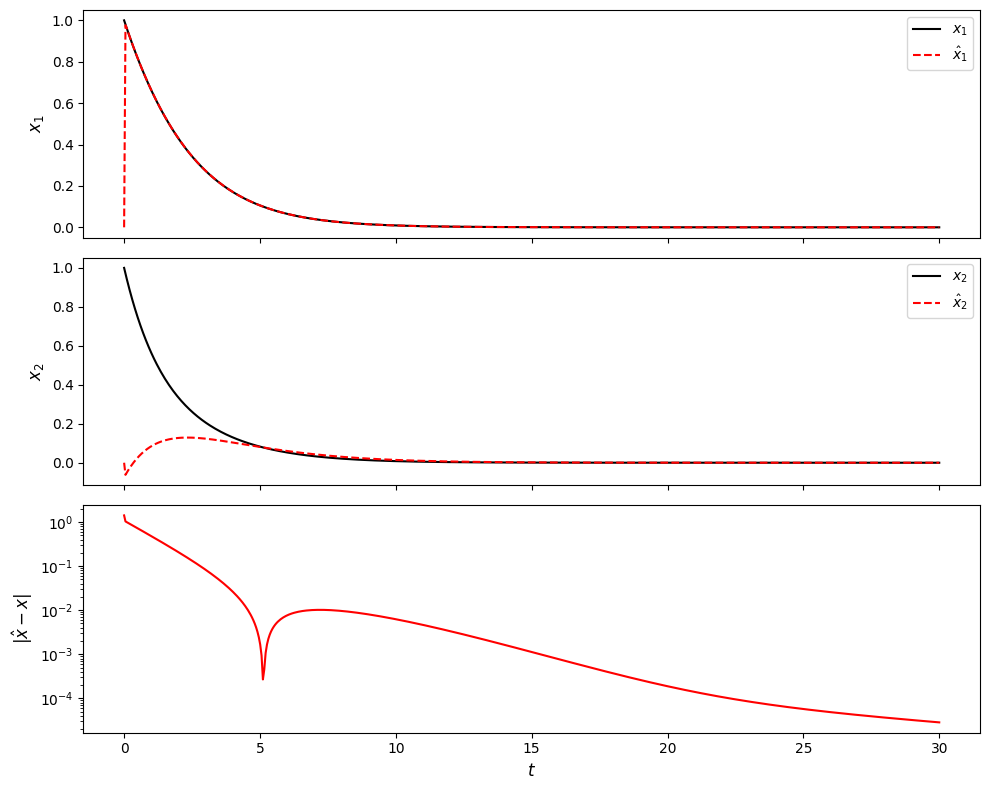

Figure saved to example1_observer.pdf


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

state_labels  = [r"$x_1$",       r"$x_2$"]
obs_labels    = [r"$\hat{x}_1$", r"$\hat{x}_2$"]

for i, ax in enumerate(axes[:2]):
    ax.plot(t_sim, x_true1[i],           color="black", lw=1.5, label=state_labels[i])
    ax.plot(obs1["t"], obs1["x_hat"][i], color="red",   lw=1.5, ls="--", label=obs_labels[i])
    ax.set_ylabel(state_labels[i], fontsize=12)
    ax.legend(fontsize=10) 

axes[2].semilogy(t_sim, np.maximum(err1, 1e-16), color="red", lw=1.5)
axes[2].set_ylabel(r"$|\hat{x} - x|$", fontsize=12)
axes[2].set_xlabel(r"$t$", fontsize=12)

plt.tight_layout()
plt.savefig("example1_observer.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to example1_observer.pdf")


## Timing summary

In [9]:
total = sum(timings.values())
print(f"{'Step':<30} {'Time (s)':>10} {'Share':>8}")
print("-" * 52)
for step, t in timings.items():
    print(f"{step:<30} {t:10.3f} {100*t/total:7.1f}%")
print("-" * 52)
print(f"{'Total':<30} {total:10.3f} {'100.0%':>8}")
print()
print("Active hyperparameters:")
for k, v in HP.items():
    print(f"  {k:<15} = {v}")

Step                             Time (s)    Share
----------------------------------------------------
1. Data collection                  0.100     4.5%
2. Kernel matrices                  0.009     0.4%
3. Observer synthesis               2.059    93.4%
4. Observer simulation              0.036     1.6%
----------------------------------------------------
Total                               2.204   100.0%

Active hyperparameters:
  lam             = 5.0
  tau             = 3.0
  n               = 64
  side_lengths    = 2.0
  s               = 2.5
  length_scale    = 1.0
  k               = 10.0
  eps             = 0.01
  delta           = 1.0
  margin          = 0.01


## Hyperparameter Tuning Study

For each group the **remaining hyperparameters are held at their baseline values** (the `HP`
dictionary defined above).  Each 2-D grid cell reports the **ISE** ($\int_0^{30}|\hat x - x|^2\,dt$) for that combination.  
Grey cells with **✗** indicate synthesis failure or an unstable closed-loop matrix.  
The **baseline combination is highlighted with a white border** in each heatmap.

In [10]:
import itertools
from matplotlib.colors import LogNorm, Normalize

def run_sweep(hp_override, seed=0):
    """Run full pipeline with HP overridden by hp_override. Returns (status, max_re, ISE)."""
    hp = {**HP, **hp_override}
    try:
        t_eval_d = np.linspace(0.0, hp["tau"], 31)
        dat = sys1.collect_data(
            side_lengths=hp["side_lengths"], n=hp["n"],
            tau=hp["tau"], t_eval=t_eval_d,
            rng=np.random.default_rng(seed),
        )
        kap = linear_kernel() * sobolev_kernel(d=2, s=hp["s"], length_scale=hp["length_scale"])
        res = synthesize_observer_gain(
            dat, kap, lam=hp["lam"],
            k=hp["k"], eps=hp["eps"], delta=hp["delta"], margin=hp["margin"],
            verbose=False,
        )
        if res["status"] not in ("optimal", "optimal_inaccurate"):
            return res["status"], np.inf, np.inf
        A_cl = res["A"] - res["L"] @ dat.Y_data
        max_re = float(np.linalg.eigvals(A_cl).real.max())
        obs = simulate_koopman_observer(
            res, dat, y_func1, np.zeros(dat.n_samples),
            t_span=(t_sim[0], t_sim[-1]), t_eval=t_sim,
        )
        err = np.linalg.norm(obs["x_hat"] - x_true1, axis=0)
        ise = float(np.trapz(err**2, t_sim))
        return res["status"], max_re, ise
    except Exception as exc:
        return f"error", np.inf, np.inf


def heatmap(ax, row_vals, col_vals, grid, row_label, col_label,
            row_fmt=str, col_fmt=str, title=None,
            baseline_row=None, baseline_col=None, log_scale=True):
    """Draw a 2-D ISE or scalar heatmap on ax."""
    finite = grid[np.isfinite(grid)]
    if finite.size == 0:
        ax.text(0.5, 0.5, "all failed", transform=ax.transAxes, ha="center")
        return
    vmin, vmax = finite.min(), finite.max()
    if log_scale and vmin > 0:
        norm = LogNorm(vmin=max(vmin * 0.9, 1e-10), vmax=vmax * 1.1)
    else:
        pad = max(abs(vmax - vmin) * 0.05, 1e-10)
        norm = Normalize(vmin=vmin - pad, vmax=vmax + pad)

    cmap = plt.cm.RdYlGn_r.copy()
    cmap.set_bad("lightgrey")
    plot_data = np.where(np.isfinite(grid), grid, np.nan)
    im = ax.imshow(plot_data, aspect="auto", origin="lower", norm=norm, cmap=cmap)
    ax.set_xticks(range(len(col_vals))); ax.set_xticklabels([col_fmt(v) for v in col_vals])
    ax.set_yticks(range(len(row_vals))); ax.set_yticklabels([row_fmt(v) for v in row_vals])
    ax.set_xlabel(col_label); ax.set_ylabel(row_label)
    if title: ax.set_title(title, fontsize=9)
    for i in range(len(row_vals)):
        for j in range(len(col_vals)):
            v = grid[i, j]
            txt = f"{v:.4f}" if np.isfinite(v) else "✗"
            ax.text(j, i, txt, ha="center", va="center", fontsize=7, color="black")
    if baseline_row is not None and baseline_col is not None:
        from matplotlib.patches import Rectangle
        ax.add_patch(Rectangle(
            (baseline_col - 0.5, baseline_row - 0.5), 1, 1,
            fill=False, edgecolor="white", lw=2.5, zorder=5,
        ))
    plt.colorbar(im, ax=ax)


### Group 1 — Yosida parameters $(\lambda,\,\tau)$

$\lambda$ controls how closely the generator matrix $M$ approximates the Koopman generator;
$\tau$ is the trajectory length used to form $M$.
All other hyperparameters are held at their baseline values.

  [ 1/25]  lam=1.0    tau=1.0  

max_re=-0.0010  ISE=0.9776  (optimal)
  [ 2/25]  lam=1.0    tau=2.0  

max_re=-0.0010  ISE=0.8995  (optimal)
  [ 3/25]  lam=1.0    tau=3.0  

max_re=-0.0010  ISE=0.8758  (optimal)
  [ 4/25]  lam=1.0    tau=5.0  

max_re=-0.0010  ISE=0.8680  (optimal)
  [ 5/25]  lam=1.0    tau=10.0  

...

max_re=-0.0029  ISE=5051.9533  (optimal)
  [22/25]  lam=20.0   tau=2.0  

max_re=+inf  ISE=inf  (error)
  [23/25]  lam=20.0   tau=3.0  

max_re=+inf  ISE=inf  (error)
  [24/25]  lam=20.0   tau=5.0  

max_re=+inf  ISE=inf  (error)
  [25/25]  lam=20.0   tau=10.0  

max_re=+inf  ISE=inf  (error)


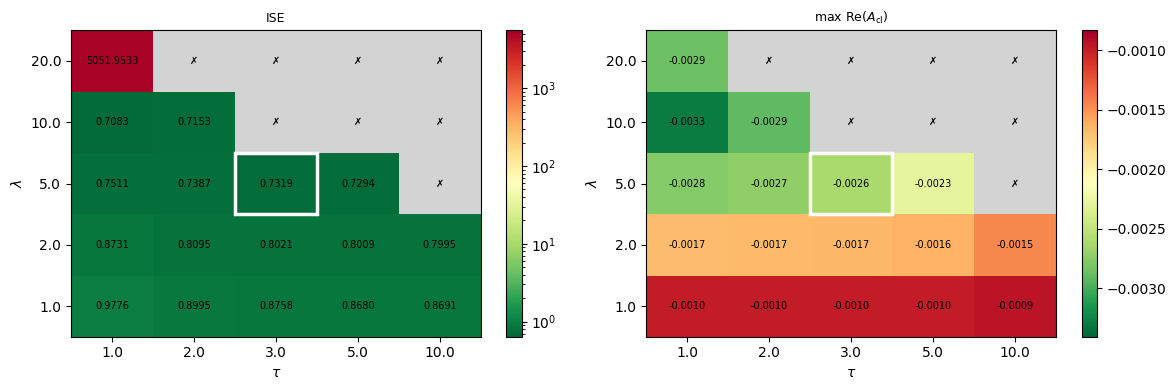

In [11]:
lam_vals = [1.0, 2.0, 5.0, 10.0, 20.0]
tau_vals  = [1.0, 2.0, 3.0, 5.0, 10.0]
g1_ise    = np.full((len(lam_vals), len(tau_vals)), np.nan)
g1_maxre  = np.full_like(g1_ise, np.nan)

total = len(lam_vals) * len(tau_vals)
for idx, (i, j) in enumerate(itertools.product(range(len(lam_vals)), range(len(tau_vals)))):
    ov = {"lam": lam_vals[i], "tau": tau_vals[j]}
    print(f"  [{idx+1:2d}/{total}]  lam={lam_vals[i]:<5}  tau={tau_vals[j]}", end="  ")
    st, mr, ise = run_sweep(ov)
    g1_ise[i, j]   = ise
    g1_maxre[i, j] = mr
    print(f"max_re={mr:+.4f}  ISE={ise:.4f}  ({st})")

bl_row1 = lam_vals.index(HP["lam"])
bl_col1 = tau_vals.index(HP["tau"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
heatmap(axes[0], lam_vals, tau_vals, g1_ise,
        r"$\lambda$", r"$\tau$", title="ISE",
        baseline_row=bl_row1, baseline_col=bl_col1, log_scale=True)
heatmap(axes[1], lam_vals, tau_vals, g1_maxre,
        r"$\lambda$", r"$\tau$", title=r"max Re$(A_{\mathrm{cl}})$",
        baseline_row=bl_row1, baseline_col=bl_col1, log_scale=False)
plt.tight_layout()
plt.savefig("example1_tuning_group1.pdf", dpi=150, bbox_inches="tight")
plt.show()


### Group 2 — Kernel parameters $(s,\,\ell)$

$s$ is the Sobolev index (controls smoothness of functions in the RKHS);
$\ell$ is the length scale of the Sobolev kernel.

  [1/25]  s=1.5   ell=0.5  

max_re=-0.5146  ISE=0.7591  (optimal)
  [2/25]  s=1.5   ell=1.0  

max_re=-0.4473  ISE=0.7316  (optimal)
  [3/25]  s=1.5   ell=1.5  

max_re=-0.3651  ISE=0.7310  (optimal)
  [4/25]  s=1.5   ell=2.0  

max_re=-0.3004  ISE=0.7313  (optimal)
  [5/25]  s=1.5   ell=2.5  

...

max_re=-0.0003  ISE=0.7318  (optimal)
  [22/25]  s=3.5   ell=1.0  

max_re=-0.0000  ISE=0.7322  (optimal)
  [23/25]  s=3.5   ell=1.5  

max_re=-0.0000  ISE=0.7301  (optimal)
  [24/25]  s=3.5   ell=2.0  

max_re=-0.0000  ISE=0.7266  (optimal)
  [25/25]  s=3.5   ell=2.5  

max_re=-0.0000  ISE=0.7243  (optimal)


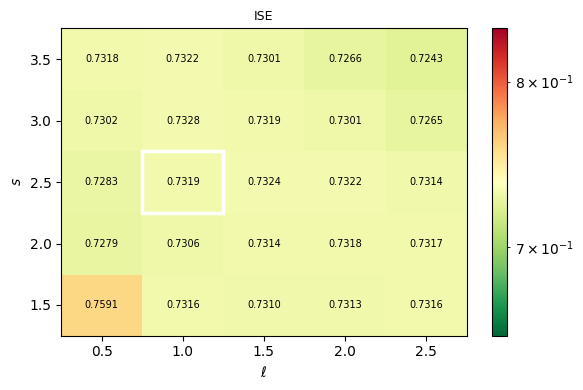

In [12]:
s_vals   = [1.5, 2.0, 2.5, 3.0, 3.5]
ell_vals = [0.5, 1.0, 1.5, 2.0, 2.5]
g2_ise   = np.full((len(s_vals), len(ell_vals)), np.nan)
g2_maxre = np.full_like(g2_ise, np.nan)

total = len(s_vals) * len(ell_vals)
for idx, (i, j) in enumerate(itertools.product(range(len(s_vals)), range(len(ell_vals)))):
    ov = {"s": s_vals[i], "length_scale": ell_vals[j]}
    print(f"  [{idx+1}/{total}]  s={s_vals[i]:<4}  ell={ell_vals[j]}", end="  ")
    st, mr, ise = run_sweep(ov)
    g2_ise[i, j]   = ise
    g2_maxre[i, j] = mr
    print(f"max_re={mr:+.4f}  ISE={ise:.4f}  ({st})")

bl_row2 = s_vals.index(HP["s"])
bl_col2 = ell_vals.index(HP["length_scale"])

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
heatmap(ax, s_vals, ell_vals, g2_ise,
        r"$s$", r"$\ell$", title="ISE",
        baseline_row=bl_row2, baseline_col=bl_col2)
plt.tight_layout()
plt.savefig("example1_tuning_group2.pdf", dpi=150, bbox_inches="tight")
plt.show()


### Group 3 — LMI solution parameters $(\varepsilon,\,\delta,\,\text{margin})$

$\varepsilon$ regularises the Gram matrix ($G = K_0 + \varepsilon I$);
$\delta$ enforces $\tilde P \succ \delta I$;
**margin** sets the strict negativity margin in the LMI.  
One heatmap of $\varepsilon \times \delta$ is drawn for each value of **margin**.

  [1/48]  margin=1e-03  eps=1e-04  delta=0.01  

max_re=-0.2347  ISE=0.7306  (optimal)
  [2/48]  margin=1e-03  eps=1e-04  delta=0.1  

max_re=-0.2347  ISE=0.7307  (optimal)
  [3/48]  margin=1e-03  eps=1e-04  delta=1.0  

max_re=-0.2347  ISE=0.7315  (optimal)
  [4/48]  margin=1e-03  eps=1e-04  delta=10.0  

max_re=-0.2347  ISE=0.7504  (optimal)
  [5/48]  margin=1e-03  eps=1e-03  delta=0.01  

...

max_re=-0.0026  ISE=0.7544  (optimal)
  [45/48]  margin=1e-01  eps=1e-01  delta=0.01  

max_re=-0.0003  ISE=0.7246  (optimal)
  [46/48]  margin=1e-01  eps=1e-01  delta=0.1  

max_re=-0.0003  ISE=0.7250  (optimal)
  [47/48]  margin=1e-01  eps=1e-01  delta=1.0  

max_re=-0.0003  ISE=0.7270  (optimal)
  [48/48]  margin=1e-01  eps=1e-01  delta=10.0  

max_re=-0.0003  ISE=0.7460  (optimal)


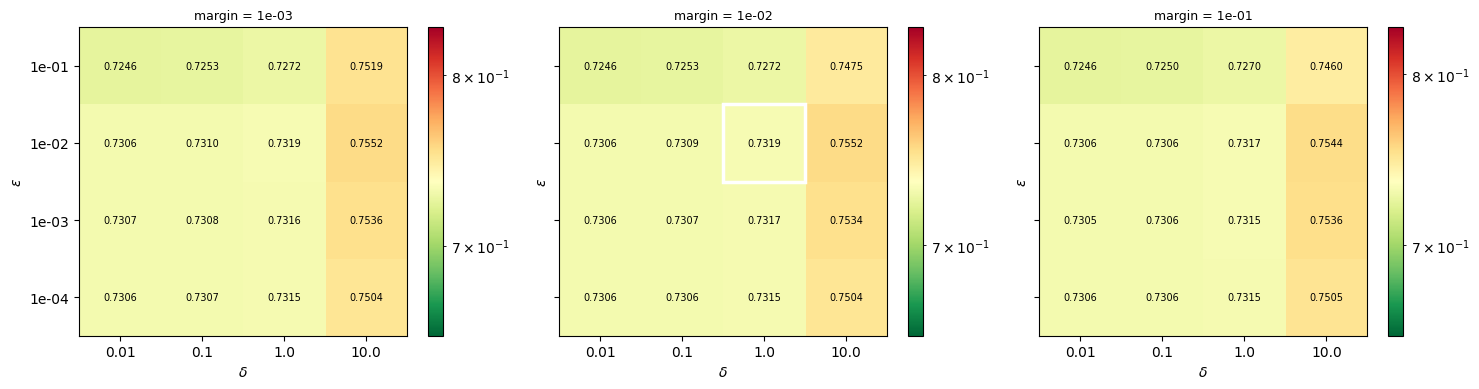

In [13]:
eps_vals    = [1e-4, 1e-3, 1e-2, 1e-1]
delta_vals  = [1e-2, 1e-1,  1e0,  1e1]
margin_vals = [1e-3, 1e-2, 1e-1]

# g3_ise[k, i, j]  =  ISE for margin_vals[k], eps_vals[i], delta_vals[j]
g3_ise   = np.full((len(margin_vals), len(eps_vals), len(delta_vals)), np.nan)
g3_maxre = np.full_like(g3_ise, np.nan)

total = len(margin_vals) * len(eps_vals) * len(delta_vals)
for idx, (k, i, j) in enumerate(itertools.product(
        range(len(margin_vals)), range(len(eps_vals)), range(len(delta_vals)))):
    ov = {"eps": eps_vals[i], "delta": delta_vals[j], "margin": margin_vals[k]}
    print(f"  [{idx+1}/{total}]  margin={margin_vals[k]:.0e}  eps={eps_vals[i]:.0e}  delta={delta_vals[j]}", end="  ")
    st, mr, ise = run_sweep(ov)
    g3_ise[k, i, j]   = ise
    g3_maxre[k, i, j] = mr
    print(f"max_re={mr:+.4f}  ISE={ise:.4f}  ({st})")

bl_k = margin_vals.index(HP["margin"])
bl_i = eps_vals.index(HP["eps"])
bl_j = delta_vals.index(HP["delta"])

eps_fmt    = lambda v: f"{v:.0e}"
delta_fmt  = lambda v: str(v)
margin_fmt = lambda v: f"{v:.0e}"

fig, axes = plt.subplots(1, len(margin_vals), figsize=(5 * len(margin_vals), 4), sharey=True)
for k, ax in enumerate(axes):
    br = bl_i if k == bl_k else None
    bc = bl_j if k == bl_k else None
    heatmap(ax, eps_vals, delta_vals, g3_ise[k],
            r"$\varepsilon$", r"$\delta$",
            row_fmt=eps_fmt, col_fmt=delta_fmt,
            title=f"margin = {margin_fmt(margin_vals[k])}",
            baseline_row=br, baseline_col=bc)
plt.tight_layout()
plt.savefig("example1_tuning_group3.pdf", dpi=150, bbox_inches="tight")
plt.show()


### Group 4 — Forcing constant $k$

$k$ appears in the LMI as the weight on the output term $k X^\top X$
(paper Eq. 19).  Larger $k$ penalises the output approximation error more strongly.

  [1/9]  k=0.1  

max_re=-0.0026  ISE=0.8436  (optimal)
  [2/9]  k=0.237  

max_re=-0.0026  ISE=0.8088  (optimal)
  [3/9]  k=0.562  

max_re=-0.0026  ISE=0.7690  (optimal)
  [4/9]  k=1.33  

max_re=-0.0026  ISE=0.7437  (optimal)
  [5/9]  k=3.16  

max_re=-0.0026  ISE=0.7340  (optimal)
  [6/9]  k=7.5  

max_re=-0.0026  ISE=0.7321  (optimal)
  [7/9]  k=17.8  

max_re=-0.0026  ISE=0.7314  (optimal)
  [8/9]  k=42.2  

max_re=-0.0026  ISE=0.7309  (optimal)
  [9/9]  k=100  

max_re=-0.0026  ISE=0.7308  (optimal)


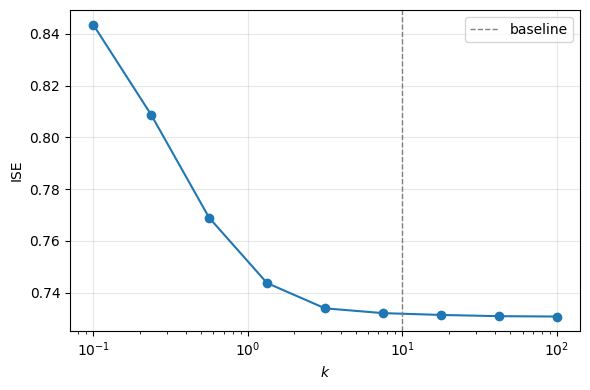

In [14]:
k_vals  = np.logspace(-1, 2, 9)
g4_ise  = []
g4_maxre = []

for idx, kv in enumerate(k_vals):
    print(f"  [{idx+1}/{len(k_vals)}]  k={kv:.3g}", end="  ")
    st, mr, ise = run_sweep({"k": kv})
    g4_ise.append(ise); g4_maxre.append(mr)
    print(f"max_re={mr:+.4f}  ISE={ise:.4f}  ({st})")

fig, ax = plt.subplots(figsize=(6, 4))
finite = [(kv, v) for kv, v in zip(k_vals, g4_ise) if np.isfinite(v)]
if finite:
    xs, ys = zip(*finite)
    ax.plot(xs, ys, "o-", color="C0")
ax.axvline(HP["k"], color="grey", ls="--", lw=1, label="baseline")
ax.set_xscale("log"); ax.set_xlabel("$k$"); ax.set_ylabel("ISE")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("example1_tuning_group4.pdf", dpi=150, bbox_inches="tight")
plt.show()


### Group 5 — Number of data points $n$

$n$ determines the size of the RKHS basis.  Larger $n$ reduces the RKHS
approximation bias but increases the cost of the LMI solve ($O(n^3)$) and
the observer ODE ($O(n^2)$).

  [1/10]  n=16  

max_re=-0.0050  ISE=0.3052  (optimal)
  [2/10]  n=20  

max_re=-0.0049  ISE=0.4619  (optimal)
  [3/10]  n=25  

max_re=-0.0028  ISE=0.6109  (optimal)
  [4/10]  n=32  

max_re=-0.0027  ISE=0.6746  (optimal)
  [5/10]  n=40  

...

max_re=-0.0026  ISE=0.5782  (optimal)
  [7/10]  n=64  

max_re=-0.0026  ISE=0.7319  (optimal)
  [8/10]  n=80  

max_re=-0.0020  ISE=0.8355  (optimal)
  [9/10]  n=101  

max_re=-0.0003  ISE=0.8085  (optimal)
  [10/10]  n=128  

max_re=-0.0003  ISE=0.8025  (optimal)


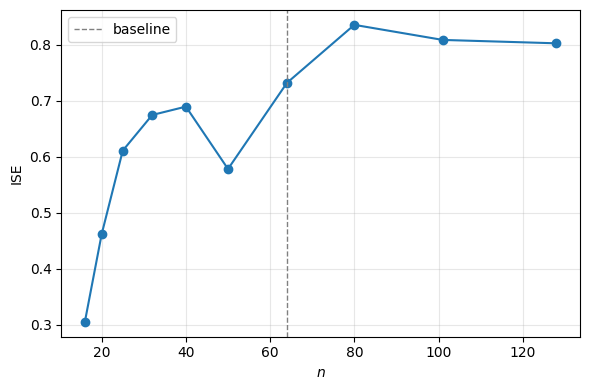

In [15]:
n_vals   = [int(2**a) for a in np.linspace(4, 7, 10)]
g5_ise   = []
g5_maxre = []

for idx, nv in enumerate(n_vals):
    print(f"  [{idx+1}/{len(n_vals)}]  n={nv}", end="  ")
    st, mr, ise = run_sweep({"n": nv})
    g5_ise.append(ise); g5_maxre.append(mr)
    print(f"max_re={mr:+.4f}  ISE={ise:.4f}  ({st})")

fig, ax = plt.subplots(figsize=(6, 4))
finite = [(nv, v) for nv, v in zip(n_vals, g5_ise) if np.isfinite(v)]
if finite:
    xs, ys = zip(*finite)
    ax.plot(xs, ys, "o-", color="C0")
ax.axvline(HP["n"], color="grey", ls="--", lw=1, label="baseline")
ax.set_xlabel("$n$"); ax.set_ylabel("ISE")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("example1_tuning_group5.pdf", dpi=150, bbox_inches="tight")
plt.show()


## Comparison with Alternative Observers

All three observers below share the **same deterministic design criterion**: find a symmetric
positive-definite $P$ and a gain matrix $L$ such that the closed-loop matrix is certified
Hurwitz by the Lyapunov inequality, with the same forcing constant $k$ as in `HP`.

| Observer | State model | Lyapunov condition |
|---|---|---|
| **Koopman–Luenberger** | RKHS Koopman generator (data-driven) | $\tilde P A + A^\top \tilde P - \tilde Y H - H^\top \tilde Y^\top + k X^\top X \preceq 0$ |
| **Linear LMI observer** | Jacobian $A_{\mathrm{lin}}$ at $x^*$ | $P_{\mathrm{lin}} A_{\mathrm{lin}} + A_{\mathrm{lin}}^\top P_{\mathrm{lin}} - Y_{\mathrm{lin}} C - C^\top Y_{\mathrm{lin}}^\top + k I \preceq 0$ |
| **Naive Luenberger** | Full nonlinear $f$ | Same LMI gain $L_{\mathrm{lin}}$ as above |

No noise covariance ($Q$, $R$) is assumed anywhere.  The only difference between the
Koopman and Linear LMI designs is the **model**: RKHS Koopman generator vs. the
finite-dimensional Jacobian linearisation.  All observers start from $\hat x_0 = 0$.

In [16]:
import cvxpy as cp

# ── Linearised system at x* = (0, 0) ─────────────────────────────────────
A_lin = np.array([[-5/4, 0.0], [1.0, -3/4]])
C_lin = np.array([[1.0, 0.0]])   # y = x1,  shape (1, 2)
d_lin = 2    # state dimension of linearised system

# ── LMI design on linearised system (same k, delta, margin as HP) ─────────
k_lin     = HP["k"]
delta_lin = HP["delta"]
mar_lin   = HP["margin"]

P_v = cp.Variable((d_lin, d_lin), symmetric=True)
Y_v = cp.Variable((d_lin, 1))          # Y_lin = P_lin L_lin

lmi_lin = (P_v @ A_lin + A_lin.T @ P_v
           - Y_v @ C_lin - C_lin.T @ Y_v.T
           + k_lin * np.eye(d_lin))

prob_lin = cp.Problem(
    cp.Minimize(cp.trace(P_v)),
    [lmi_lin << -mar_lin * np.eye(d_lin),
     P_v    >> delta_lin * np.eye(d_lin)],
)
prob_lin.solve(solver="MOSEK", verbose=False)

P_lin = P_v.value
Y_lin = Y_v.value
L_lin = np.linalg.solve(P_lin, Y_lin)   # (2, 1)  gain

A_cl_lin = A_lin - L_lin @ C_lin
print(f"Linear LMI status           : {prob_lin.status}")
print(f"Linear LMI gain L_lin       = {L_lin.ravel()}")
print(f"Linear LMI closed-loop eigs = {np.sort(np.linalg.eigvals(A_cl_lin).real)}")

# ── Simulate: Linear LMI observer ─────────────────────────────────────────
x0_obs = np.zeros(2)

def lin_lmi_rhs(t, xh):
    yt = y_func1(t)[0]
    return A_lin @ xh + L_lin[:, 0] * (yt - C_lin @ xh)

sol_lin = solve_ivp(lin_lmi_rhs, [t_sim[0], t_sim[-1]], x0_obs,
                    method="Radau", rtol=1e-8, atol=1e-10, t_eval=t_sim)

# ── Simulate: Naive Luenberger  ẋ̂ = f(x̂) + L_lin(y − h(x̂)) ────────────
def naive_rhs(t, xh):
    yt = y_func1(t)[0]
    return f_ex1(xh) + L_lin[:, 0] * (yt - xh[0])

sol_naive = solve_ivp(naive_rhs, [t_sim[0], t_sim[-1]], x0_obs,
                      method="Radau", rtol=1e-8, atol=1e-10, t_eval=t_sim)

# ── Error norms and ISE ───────────────────────────────────────────────────
err_koop  = np.linalg.norm(obs1["x_hat"] - x_true1, axis=0)
err_lin   = np.linalg.norm(sol_lin.y     - x_true1, axis=0)
err_naive = np.linalg.norm(sol_naive.y   - x_true1, axis=0)

ise_koop  = float(np.trapz(err_koop**2,  t_sim))
ise_lin   = float(np.trapz(err_lin**2,   t_sim))
ise_naive = float(np.trapz(err_naive**2, t_sim))

print(f"\n{'Observer':<25} {'ISE':>10}")
print("-" * 37)
for name, ise in [("Koopman–Luenberger", ise_koop),
                  ("Linear LMI observer", ise_lin),
                  ("Naive Luenberger",    ise_naive)]:
    print(f"  {name:<23} {ise:10.4f}")


Linear LMI status           : optimal
Linear LMI gain L_lin       = [4.63042136 1.        ]
Linear LMI closed-loop eigs = [-5.88042136 -0.75      ]

Observer                         ISE
-------------------------------------
  Koopman–Luenberger          0.7319
  Linear LMI observer         0.7348
  Naive Luenberger            0.5839


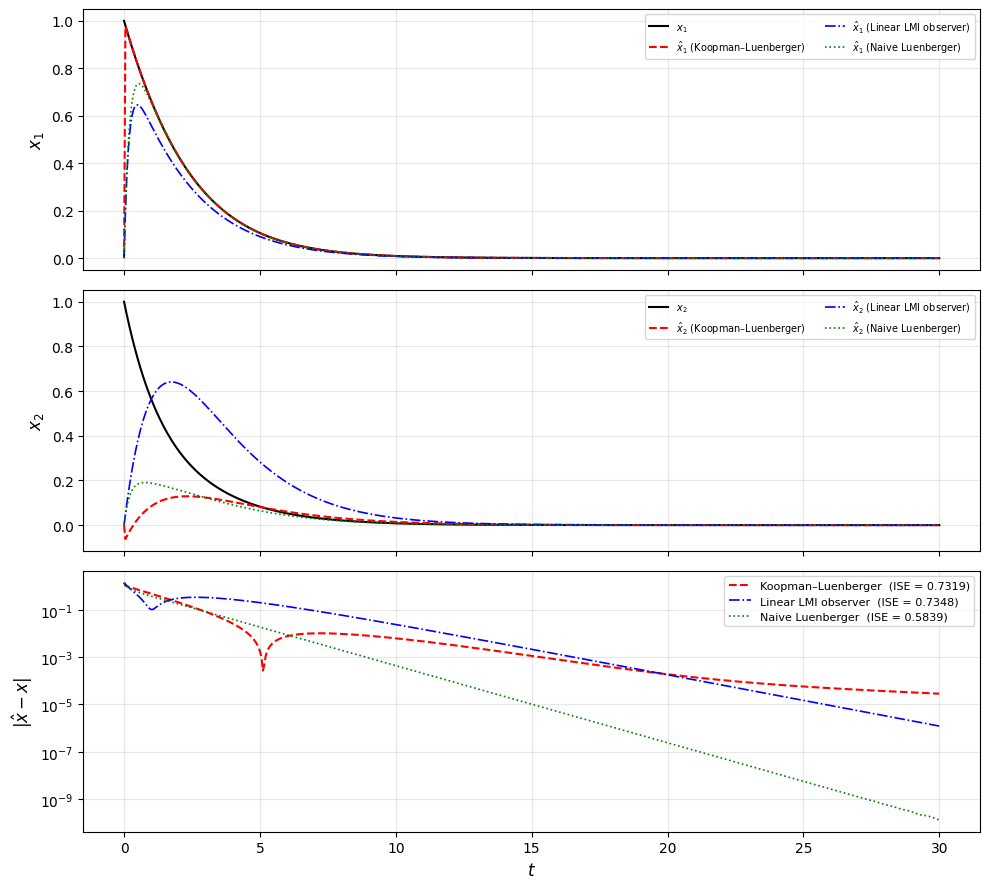

Figure saved to example1_comparison.pdf


In [17]:
styles = {
    "True":               dict(color="black",  lw=1.5, ls="-"),
    "Koopman–Luenberger": dict(color="red",    lw=1.5, ls="--"),
    "Linear LMI observer":dict(color="blue",   lw=1.2, ls="-."),
    "Naive Luenberger":   dict(color="green",  lw=1.2, ls=":"),
}
xhats = {
    "Koopman–Luenberger":  obs1["x_hat"],
    "Linear LMI observer": sol_lin.y,
    "Naive Luenberger":    sol_naive.y,
}
ises = {
    "Koopman–Luenberger":  ise_koop,
    "Linear LMI observer": ise_lin,
    "Naive Luenberger":    ise_naive,
}
errs = {
    "Koopman–Luenberger":  err_koop,
    "Linear LMI observer": err_lin,
    "Naive Luenberger":    err_naive,
}

state_syms = [r"$x_1$", r"$x_2$"]
hat_syms   = [r"$\hat{x}_1$", r"$\hat{x}_2$"]

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for i, ax in enumerate(axes[:2]):
    ax.plot(t_sim, x_true1[i], label=state_syms[i], **styles["True"])
    for name, xh in xhats.items():
        ax.plot(t_sim, xh[i], label=f"{hat_syms[i]} ({name})", **styles[name])
    ax.set_ylabel(state_syms[i], fontsize=12)
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

for name, er in errs.items():
    axes[2].semilogy(t_sim, np.maximum(er, 1e-16),
                     label=f"{name}  (ISE = {ises[name]:.4f})",
                     **styles[name])
axes[2].set_ylabel(r"$|\hat{x} - x|$", fontsize=12)
axes[2].set_xlabel(r"$t$", fontsize=12)
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("example1_comparison.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to example1_comparison.pdf")


## Comparison with Neural-Network KKL Observer

The **Kazantzis–Kravaris / Luenberger (KKL) observer** transforms the state
$x$ via a coordinate map $T: x \mapsto z$ that satisfies the PDE
$$\frac{\partial T}{\partial x}\,f(x) = D\,T(x) + E\,h(x),$$
with $D$ stable and prescribed.  Online, one runs the **linear** ODE
$$\dot z = D z + E\,y(t)$$
and recovers $\hat x = T^\dagger(z)$ via the learned inverse map.

Both maps $T$ and $T^\dagger$ are parameterised as MLPs and trained on the
**same $n=64$ trajectory data** already collected in Step 1 (`data1`).

| Parameter | Value |
|---|---|
| $D$ | diag$(-1,-2)$ |
| $E$ | $[1,1]^	op$ |
| Embedding dim $q$ | 2 |
| MLP architecture | 2 hidden layers, 32 units, tanh |

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.interpolate import interp1d

# ── KKL hyperparameters ───────────────────────────────────────────────────
KKL_HP = {
    "q":       2,           # embedding dimension (= state dim)
    "D_eigs":  [-1., -2.],  # eigenvalues of D (must be stable)
    "E":       [1., 1.],    # E column vector entries (scalar output)
    "width":   32,          # MLP hidden units per layer
    "depth":   2,           # number of hidden layers
    "lr":      1e-3,        # Adam learning rate
    "epochs":  5000,        # training epochs per map
}

# ── Build KKL matrices ────────────────────────────────────────────────────
q_kkl = KKL_HP["q"]
D_kkl = np.diag(KKL_HP["D_eigs"])        # (q, q)
E_kkl = np.array(KKL_HP["E"])            # (q,)  — scalar output

# ── Generate z(t) for each training trajectory ───────────────────────────
# Integrate ż = D z + E y(t) from z(0)=0, consistent with all other observers.
n_traj = data1.n_samples               # 64
t_data = np.linspace(0., HP["tau"], 31) # same grid as data collection

print("Generating z training data …")
t0_kkl = time.perf_counter()

z_traj = np.zeros((q_kkl, 31, n_traj))
for i in range(n_traj):
    y_i = data1.Y_traj[0, :, i]          # (31,) — scalar output
    y_interp = interp1d(t_data, y_i, kind="cubic", fill_value="extrapolate")

    def _rhs(t, z, _yi=y_interp):
        return D_kkl @ z + E_kkl * float(_yi(t))

    sol_z = solve_ivp(_rhs, [0., HP["tau"]], np.zeros(q_kkl),
                      method="Radau", t_eval=t_data, rtol=1e-8, atol=1e-10)
    z_traj[:, :, i] = sol_z.y

timings["KKL data"] = time.perf_counter() - t0_kkl
print(f"  done in {timings['KKL data']:.2f}s")

# Flatten (q, N_t, n) → (N_t*n, q) — axes order is the same for both arrays
X_train_kkl = data1.X_traj.reshape(2, -1).T   # (1984, 2)
Z_train_kkl = z_traj.reshape(q_kkl, -1).T     # (1984, 2)
print(f"Training pairs: {X_train_kkl.shape[0]}")


Generating z training data …


  done in 0.73s
Training pairs: 1984


In [19]:
torch.manual_seed(42)

class ZeroAtOriginMLP(nn.Module):
    """MLP with T(0)=0 enforced by subtracting the network's own value at 0."""
    def __init__(self, in_dim, out_dim, width, depth):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x0 = torch.zeros(1, x.shape[-1], dtype=x.dtype, device=x.device)
        return self.net(x) - self.net(x0)

d_state = sys1.n_states   # 2
T_net    = ZeroAtOriginMLP(d_state, q_kkl, KKL_HP["width"], KKL_HP["depth"])
Tinv_net = ZeroAtOriginMLP(q_kkl, d_state, KKL_HP["width"], KKL_HP["depth"])

X_t = torch.tensor(X_train_kkl, dtype=torch.float32)
Z_t = torch.tensor(Z_train_kkl, dtype=torch.float32)
loss_fn = nn.MSELoss()

def _train(net, x_in, y_tgt, label):
    opt = optim.Adam(net.parameters(), lr=KKL_HP["lr"])
    ep_print = KKL_HP["epochs"] // 4
    for ep in range(KKL_HP["epochs"]):
        opt.zero_grad()
        loss = loss_fn(net(x_in), y_tgt)
        loss.backward()
        opt.step()
        if (ep + 1) % ep_print == 0:
            print(f"  {label}  ep {ep+1:5d}  loss = {loss.item():.6f}")
    return loss.item()

print("Training T  (x \u2192 z) \u2026")
t0_T = time.perf_counter()
loss_T = _train(T_net, X_t, Z_t, "T   ")
timings["KKL train T"] = time.perf_counter() - t0_T
print(f"  final MSE = {loss_T:.6f}  ({timings['KKL train T']:.1f}s)")

print(""); print("Training T\u207b\u00b9 (z \u2192 x) \u2026")
t0_Ti = time.perf_counter()
loss_Ti = _train(Tinv_net, Z_t, X_t, "T\u207b\u00b9")
timings["KKL train Tinv"] = time.perf_counter() - t0_Ti
print(f"  final MSE = {loss_Ti:.6f}  ({timings['KKL train Tinv']:.1f}s)")

# Sanity check: T(0) and T†(0) must both be [0,0] by construction
with torch.no_grad():
    print(f"T(0)  = {T_net(torch.zeros(1, d_state)).numpy().ravel()}")
    print(f"T\u2020(0) = {Tinv_net(torch.zeros(1, q_kkl)).numpy().ravel()}")


Training T  (x → z) …


  T     ep  1250  loss = 0.003546


  T     ep  2500  loss = 0.003154


  T     ep  3750  loss = 0.002896


  T     ep  5000  loss = 0.002717
  final MSE = 0.002717  (4.6s)

Training T⁻¹ (z → x) …


  T⁻¹  ep  1250  loss = 0.056619


  T⁻¹  ep  2500  loss = 0.053371


  T⁻¹  ep  3750  loss = 0.050936


  T⁻¹  ep  5000  loss = 0.049602
  final MSE = 0.049602  (4.1s)
T(0)  = [0. 0.]
T†(0) = [0. 0.]


KKL observer ISE = 0.3572


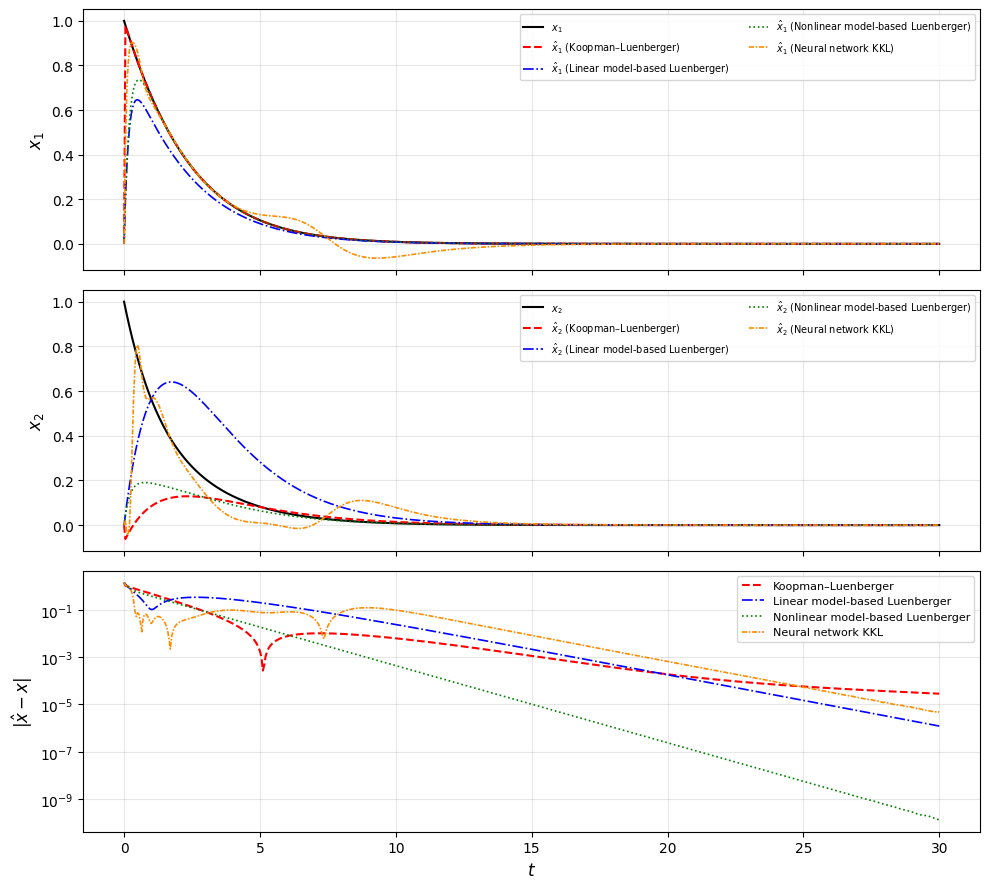


Figure saved to example1_comparison_kkl.pdf

Observer                                   ISE
-----------------------------------------------
  Koopman–Luenberger                    0.7319
  Linear model-based Luenberger         0.7348
  Nonlinear model-based Luenberger      0.5839
  Neural network KKL                    0.3572


In [20]:
# ── KKL observer simulation ───────────────────────────────────────────────
def _kkl_rhs(t, z):
    return D_kkl @ z + E_kkl * float(y_func1(t)[0])

t0_ks = time.perf_counter()
sol_kkl_z = solve_ivp(_kkl_rhs, [t_sim[0], t_sim[-1]], np.zeros(q_kkl),
                      method="Radau", rtol=1e-8, atol=1e-10, t_eval=t_sim)
timings["KKL simulate"] = time.perf_counter() - t0_ks

with torch.no_grad():
    Z_sim_t  = torch.tensor(sol_kkl_z.y.T, dtype=torch.float32)  # (N_sim, q)
    xhat_kkl = Tinv_net(Z_sim_t).numpy().T                        # (2, N_sim)

err_kkl = np.linalg.norm(xhat_kkl - x_true1, axis=0)
ise_kkl = float(np.trapz(err_kkl**2, t_sim))
print(f"KKL observer ISE = {ise_kkl:.4f}")

# ── Combined 4-observer comparison plot ──────────────────────────────────
styles4 = {
    "True":                              dict(color="black",     lw=1.5, ls="-"),
    "Koopman\u2013Luenberger":          dict(color="red",       lw=1.5, ls="--"),
    "Linear model-based Luenberger":     dict(color="blue",      lw=1.2, ls="-."),
    "Nonlinear model-based Luenberger":  dict(color="green",     lw=1.2, ls=":"),
    "Neural network KKL":                dict(color="darkorange",lw=1.2, ls=(0,(3,1,1,1))),
}
xhats4 = {
    "Koopman\u2013Luenberger":          obs1["x_hat"],
    "Linear model-based Luenberger":     sol_lin.y,
    "Nonlinear model-based Luenberger":  sol_naive.y,
    "Neural network KKL":                xhat_kkl,
}
ises4 = {
    "Koopman\u2013Luenberger":          ise_koop,
    "Linear model-based Luenberger":     ise_lin,
    "Nonlinear model-based Luenberger":  ise_naive,
    "Neural network KKL":                ise_kkl,
}
errs4 = {
    "Koopman\u2013Luenberger":          err_koop,
    "Linear model-based Luenberger":     err_lin,
    "Nonlinear model-based Luenberger":  err_naive,
    "Neural network KKL":                err_kkl,
}

state_syms = [r"$x_1$", r"$x_2$"]
hat_syms   = [r"$\hat{x}_1$", r"$\hat{x}_2$"]

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for i, ax in enumerate(axes[:2]):
    ax.plot(t_sim, x_true1[i], label=state_syms[i], **styles4["True"])
    for name, xh in xhats4.items():
        ax.plot(t_sim, xh[i], label=f"{hat_syms[i]} ({name})", **styles4[name])
    ax.set_ylabel(state_syms[i], fontsize=12)
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

for name, er in errs4.items():
    axes[2].semilogy(t_sim, np.maximum(er, 1e-16),
                     label=name, **styles4[name])
axes[2].set_ylabel(r"$|\hat{x} - x|$", fontsize=12)
axes[2].set_xlabel(r"$t$", fontsize=12)
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("example1_comparison_kkl.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("\nFigure saved to example1_comparison_kkl.pdf")
print(f"\n{'Observer':<35} {'ISE':>10}")
print("-" * 47)
for name, ise in ises4.items():
    print(f"  {name:<33} {ise:10.4f}")
